# EDA (Exploratory Data Analysis)

1. load datasets

2. clean data (missing values, duplicate, types)

3. treat outliers

4. Univariate , bivariate and multivariate analysis

5. insights

### outlier - a data point that is significantly different from other observations in a dataset .

# How outliers will come ?
1. Measurement Errors
2. Data entry mistakes

# Why they are important ?
1. They can be errors
2. They effect the data analysis

# How to identify the outliers ?
1. statistical Methods
    > Interquartile Range (IQR)
    > Z-Score
2. Visualization Tech
    > Box Plots
    > Scatter Plots
    > Histograms


### Univariate analysis  - a method that analyzes a single variable to describe its characteristics, finding patterns and summarize the data.

#### It involves only one variable.

### Bivariate analysis - it will give the relationship b/w 2 variables. It helps to find if there is an co-relation, association or connection b/w the 2 variables.

#### It involves 2 variables (x & y)

### Multivariate analysis - To understand how multiple factors interact and influence each other 

#### It involves more than 2

Example- 
How our age, income, and education level together influence the purchasing behaviour.

# ETL 

## EDA : <Dataset>

1. Load & Overview

2.Cleaning (missing, dupes, dtypes)

3. uni, Bi& Multi analysis

4. Outlier - IQR

5. Feature Engineering

6. Key Insights


### Feature Engineering - " F.E is the process of turning raw data into useful features " that helps to improve the performance of machine learning models.

In [ ]:
# 1.Load libraries & Dataset

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Basic information and overview
print("Shape of dataset:", df.shape)
print("\nData info:\n")
df.info()

# Summary statistics
df.describe(include='all')


Shape of dataset: (891, 15)

Data info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Missing values analysis

missing=pd.DataFrame({
    'missing count':df.isnull().sum(),
    'missing_percent':(df.isnull().sum()/ len(df))*100
})
missing.sort_values(by ='missing_percent',ascending=False)

,missing count,missing_percent
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
sex,0,0.000000
pclass,0,0.000000
survived,0,0.000000
fare,0,0.000000
parch,0,0.000000
sibsp,0,0.000000


In [5]:
# 4. handling missing values

# Fill numeric missing values with the mean
df['age'] = df['age'].fillna(df['age'].mean())

# Fill categorical missing values with the mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop 'deck' column (too many missing values)
df.drop(columns=['deck'], inplace=True)

print("Missing values after cleaning:\n", df.isnull().sum().sum())



Missing values after cleaning:
 2


### Insight: 
1. we filled important columns and removed highly missing ones.This keeps maximum information while making the dataset clean.

In [6]:
# Duplicates and data type check
print("Duplicate rows:",df.duplicated().sum())

# convert some columns to category type
df['class']=df['class'].astype('category')
df['sex']=df['sex'].astype('category')
df['embarked']=df['embarked'].astype('category')

df.info()

Duplicate rows: 111
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    category
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    category
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(3), float64(2), int64(4), object(3)
memory usage: 67.5+ KB


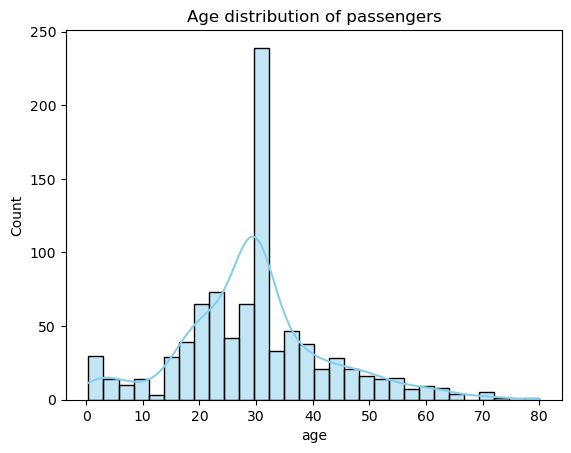

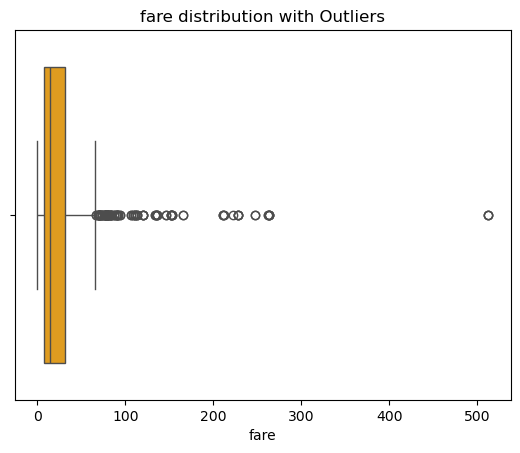

In [7]:
# 6.Univariate Analysis - Numerical Features

num_cols=df.select_dtypes(include=['float64','int64']).columns
df[num_cols].describe()

#Histogram : Age
sns.histplot(df['age'],bins=30,kde=True,color='skyblue')
plt.title('Age distribution of passengers')
plt.show()

#Boxplot: fare
sns.boxplot(x=df['fare'],color='orange')
plt.title("fare distribution with Outliers")
plt.show()

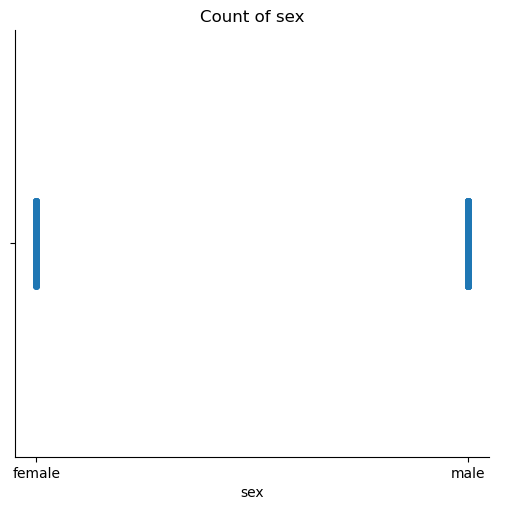

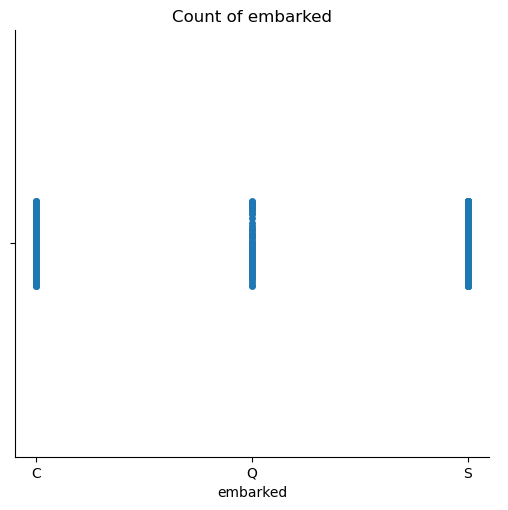

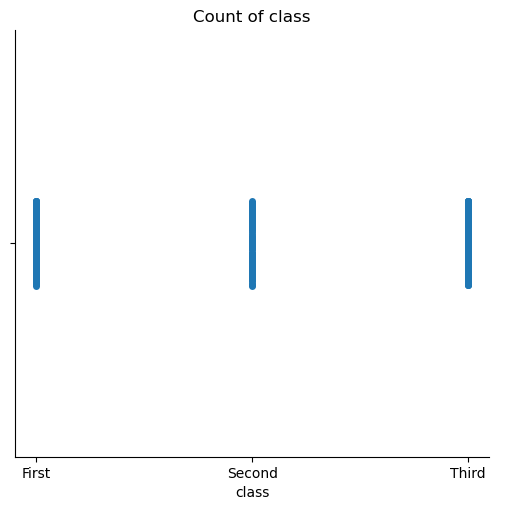

In [8]:
cat_clos=df.select_dtypes("category").columns
for col in cat_clos:
    sns.catplot(x=col, data=df)
    plt.title(f"Count of {col}")
    plt.show()

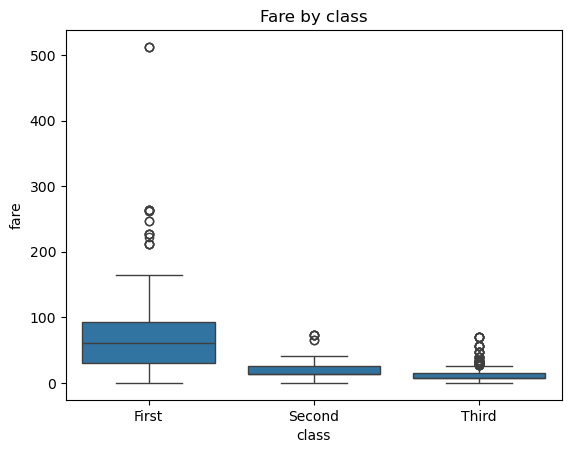

In [9]:
# Bivariate Analysis - Numerical vs Categorical

sns.boxplot(x='class',y='fare',data=df)
plt.title("Fare by class")
plt.show()


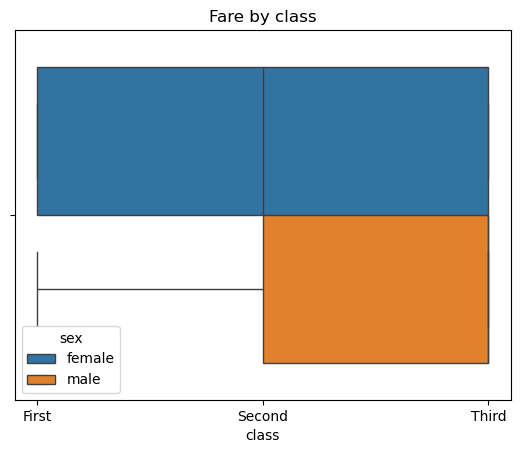

In [11]:
# Bivariate Analysis - Numerical vs Categorical

sns.boxplot(x='class',hue='sex',data=df)
plt.title("Fare by class")
plt.show()


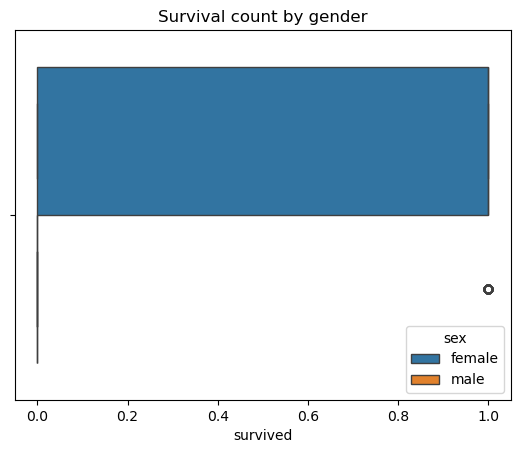

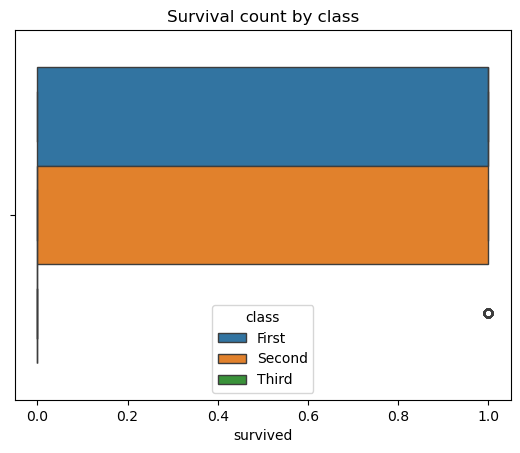

In [12]:
# Bivariate Analysis - Numerical vs Categorical

sns.boxplot(x='survived',hue='sex',data=df)
plt.title("Survival count by gender")
plt.show()

sns.boxplot(x='survived',hue='class',data=df)
plt.title("Survival count by class")
plt.show()



In [13]:
# Corelation and multivariate 

corr= df[['age','fare','survived']].core()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation heatmap")
plt.show()

AttributeError: 'DataFrame' object has no attribute 'core'